# 수면 검출 추론 (Water Segmentation Inference)

학습이 끝난 `best.pt`를 불러와 **이미지 → 수면 마스크**를 뽑는 노트북입니다.

**지원 입력**
- 단일 이미지 1장
- 폴더 전체 (배치 처리 + CSV 저장)
- 동영상 / CCTV 스트림

**출력**
- 수면 오버레이 이미지
- `water_ratio` (프레임 내 수면 픽셀 비율)
- `water_line_y` (수면 최상단 y좌표)
- 바퀴 bbox 연동 시 침수 레벨 0~4

## 1. 모델 로드

In [9]:
import os, sys, json, glob, csv, time
from pathlib import Path

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ── 여기만 수정 ──────────────────────────────────────────────
WEIGHTS = r"C:\Project\PythonProject\PyTorch001\runs_water\exported\water_seg_best.pt"
CONF    = 0.25    # 신뢰도 임계값 (낮추면 더 많이 잡음)
IOU     = 0.45
IMGSZ   = 640
# ────────────────────────────────────────────────────────────

DEVICE = 0 if torch.cuda.is_available() else "cpu"

# 경로가 틀렸을 때를 대비해 runs 폴더에서 자동 탐색
if not Path(WEIGHTS).exists():
    print(f"[!] 지정 경로 없음: {WEIGHTS}")
    cands = sorted(Path(r"C:\Project\PythonProject\PyTorch001").rglob("weights/best.pt"),
                   key=lambda p: p.stat().st_mtime, reverse=True)
    if cands:
        WEIGHTS = str(cands[0])
        print(f"[자동탐색] 가장 최근 가중치 사용 → {WEIGHTS}")
    else:
        raise FileNotFoundError("best.pt 를 찾지 못했습니다. 학습이 완료되었는지 확인하세요.")

model = YOLO(WEIGHTS)
print("모델 로드 완료 |", WEIGHTS)
print("클래스     :", model.names)
print("디바이스   :", "GPU " + torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU")

모델 로드 완료 | C:\Project\PythonProject\PyTorch001\runs_water\exported\water_seg_best.pt
클래스     : {0: 'water'}
디바이스   : GPU NVIDIA GeForce RTX 5060 Laptop GPU


## 2. 핵심 함수 — 이미지 1장 → 수면 마스크

인스턴스 마스크를 전부 OR로 합쳐 **하나의 수면 영역**으로 만듭니다.
침수 판정에는 "물이 몇 덩어리인가"가 아니라 "어디까지 잠겼는가"만 필요하기 때문입니다.

In [10]:
def detect_water(image, conf=CONF, iou=IOU):
    '''
    image : 파일경로(str/Path) 또는 BGR ndarray
    return: dict(img_rgb, mask, ratio, water_y, n_inst, ms)
    '''
    if isinstance(image, (str, Path)):
        bgr = cv2.imread(str(image))
        if bgr is None:
            raise FileNotFoundError(f"이미지를 읽을 수 없습니다: {image}")
    else:
        bgr = image

    h, w = bgr.shape[:2]
    t0 = time.perf_counter()
    r = model.predict(source=bgr, conf=conf, iou=iou, imgsz=IMGSZ,
                      device=DEVICE, verbose=False)[0]
    ms = (time.perf_counter() - t0) * 1000

    mask = np.zeros((h, w), dtype=np.uint8)
    n_inst = 0
    if r.masks is not None:
        for m in r.masks.data.cpu().numpy():
            m = cv2.resize(m.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
            mask |= (m > 0.5).astype(np.uint8)
            n_inst += 1

    ys = np.where(mask.any(axis=1))[0]
    return {
        "img_rgb": cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
        "mask": mask,
        "ratio": float(mask.mean()),
        "water_y": int(ys.min()) if len(ys) else None,
        "n_inst": n_inst,
        "ms": ms,
    }


def overlay(img_rgb, mask, color=(0, 140, 255), alpha=0.45, draw_line=True):
    '''수면 영역을 반투명 색으로 덮고 수면선을 그림'''
    vis = img_rgb.copy()
    idx = mask == 1
    if idx.any():
        vis[idx] = (alpha * np.array(color) + (1 - alpha) * vis[idx]).astype(np.uint8)
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(vis, cnts, -1, (0, 255, 255), 2)
        if draw_line:
            y = int(np.where(mask.any(axis=1))[0].min())
            cv2.line(vis, (0, y), (vis.shape[1], y), (255, 0, 0), 2)
            cv2.putText(vis, f"water line y={y}", (10, max(y - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return vis

## 3. 단일 이미지 테스트

폴더가 지정되어 첫 이미지를 사용합니다: KakaoTalk_20260804_143732535.png


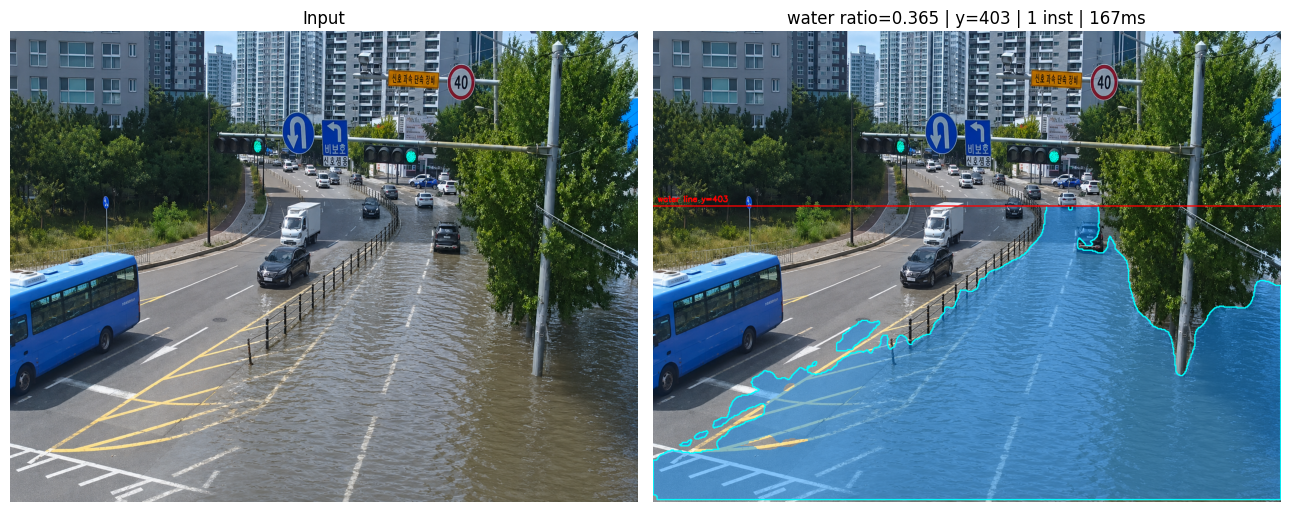

{
  "ratio": 0.3645448602505011,
  "water_y": 403,
  "n_inst": 1,
  "ms": 166.76460000235238
}


In [11]:
# ── 검사할 이미지 경로 ──
IMG_PATH = r"C:\Users\Win11Pro\Downloads\물이미지"

p = Path(IMG_PATH)
if p.is_dir():   # 폴더를 넣었으면 첫 장 자동 선택
    p = sorted(list(p.glob("*.jpg")) + list(p.glob("*.png")))[0]
    print("폴더가 지정되어 첫 이미지를 사용합니다:", p.name)

res = detect_water(p)
vis = overlay(res["img_rgb"], res["mask"])

plt.figure(figsize=(13, 6))
plt.subplot(1, 2, 1); plt.imshow(res["img_rgb"]); plt.title("Input"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(vis); plt.axis("off")
plt.title(f"water ratio={res['ratio']:.3f} | y={res['water_y']} | {res['n_inst']} inst | {res['ms']:.0f}ms")
plt.tight_layout(); plt.show()

print(json.dumps({k: v for k, v in res.items() if k not in ("img_rgb", "mask")},
                 ensure_ascii=False, indent=2))

## 4. 폴더 배치 처리 → CSV 저장

여러 장을 한 번에 돌려 결과를 표로 남깁니다. 결과 CSV는 발표용 정량 지표로 바로 쓸 수 있습니다.

In [4]:
def run_folder(src_dir, out_dir=None, save_vis=True, limit=None):
    src_dir = Path(src_dir)
    files = sorted([f for f in src_dir.iterdir()
                    if f.suffix.lower() in (".jpg", ".jpeg", ".png")])
    if limit:
        files = files[:limit]
    if not files:
        print("이미지가 없습니다:", src_dir); return []

    out_dir = Path(out_dir) if out_dir else src_dir.parent / "water_pred"
    (out_dir / "vis").mkdir(parents=True, exist_ok=True)
    (out_dir / "mask").mkdir(parents=True, exist_ok=True)

    rows = []
    for i, f in enumerate(files, 1):
        try:
            r = detect_water(f)
        except Exception as e:
            print(f"[skip] {f.name}: {e}"); continue

        rows.append({"file": f.name, "water_ratio": round(r["ratio"], 5),
                     "water_line_y": r["water_y"], "n_instances": r["n_inst"],
                     "infer_ms": round(r["ms"], 1)})

        if save_vis:
            vis = overlay(r["img_rgb"], r["mask"])
            cv2.imwrite(str(out_dir / "vis" / f.name), cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
            cv2.imwrite(str(out_dir / "mask" / (f.stem + "_mask.png")), r["mask"] * 255)

        if i % 25 == 0 or i == len(files):
            print(f"  {i}/{len(files)} 처리")

    csv_path = out_dir / "water_results.csv"
    with open(csv_path, "w", newline="", encoding="utf-8-sig") as fp:
        wtr = csv.DictWriter(fp, fieldnames=list(rows[0].keys()))
        wtr.writeheader(); wtr.writerows(rows)

    print(f"\n완료 | {len(rows)}장")
    print("CSV      :", csv_path)
    print("오버레이 :", out_dir / "vis")
    return rows


rows = run_folder(r"C:\Project\PythonProject\PyTorch001\datasets\water_seg\images\test",
                  save_vis=True, limit=None)

  25/54 처리
  50/54 처리
  54/54 처리

완료 | 54장
CSV      : C:\Project\PythonProject\PyTorch001\datasets\water_seg\images\water_pred\water_results.csv
오버레이 : C:\Project\PythonProject\PyTorch001\datasets\water_seg\images\water_pred\vis


평균 수면비율 0.2364 | 최소 0.0000 | 최대 0.6469
물 미검출(ratio=0) : 2장 / 54장
평균 추론속도       : 49.2 ms/frame (20.3 FPS)


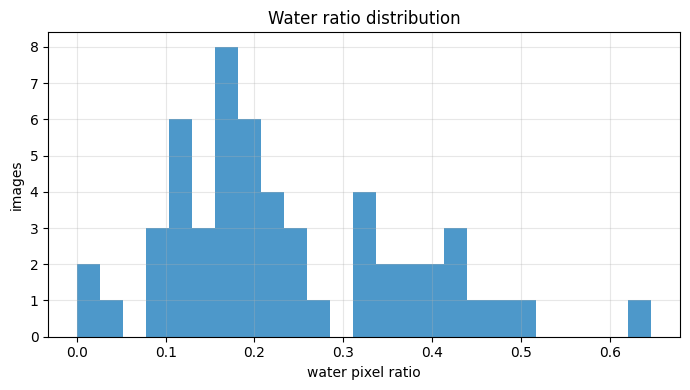

In [5]:
# 결과 요약
if rows:
    ratios = np.array([r["water_ratio"] for r in rows])
    print(f"평균 수면비율 {ratios.mean():.4f} | 최소 {ratios.min():.4f} | 최대 {ratios.max():.4f}")
    print(f"물 미검출(ratio=0) : {(ratios == 0).sum()}장 / {len(ratios)}장")
    print(f"평균 추론속도       : {np.mean([r['infer_ms'] for r in rows]):.1f} ms/frame "
          f"({1000 / np.mean([r['infer_ms'] for r in rows]):.1f} FPS)")

    plt.figure(figsize=(7, 4))
    plt.hist(ratios, bins=25, color="#2E86C1", alpha=0.85)
    plt.xlabel("water pixel ratio"); plt.ylabel("images")
    plt.title("Water ratio distribution"); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 5. 침수 레벨 판정 — 바퀴 bbox 연동

2단계(바퀴 검출) 모델의 bbox를 넣으면 잠김 비율과 레벨을 반환합니다.
바퀴 검출 결과가 아직 없으면 아래 `WHEEL_BOXES`에 수동 좌표를 넣어 동작을 확인하세요.

C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL S

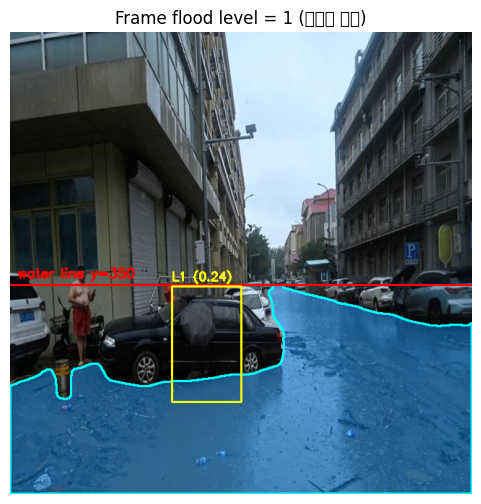

{'wheel': 0, 'pixel_ratio': 0.2048, 'height_ratio': 0.2375, 'water_y': 474, 'level': 1, 'desc': '타이어 하단'}


In [6]:
LEVEL_DESC = {0: "정상", 1: "타이어 하단", 2: "휠 림 하단", 3: "휠 림 상단", 4: "타이어 완전 침수"}

def wheel_submersion(mask, box):
    x1, y1, x2, y2 = [int(v) for v in box]
    h, w = mask.shape
    x1, x2 = max(0, x1), min(w, x2)
    y1, y2 = max(0, y1), min(h, y2)
    if x2 <= x1 or y2 <= y1:
        return {"pixel_ratio": 0.0, "height_ratio": 0.0, "water_y": None}

    roi = mask[y1:y2, x1:x2]
    col = mask[:, x1:x2]
    ys = np.where(col.any(axis=1))[0]
    wy = int(ys.min()) if len(ys) else None
    height_ratio = 0.0 if wy is None else float(np.clip((y2 - max(wy, y1)) / (y2 - y1), 0, 1))
    return {"pixel_ratio": round(float(roi.mean()), 4),
            "height_ratio": round(height_ratio, 4), "water_y": wy}


def level_from_ratio(hr):
    if hr < 0.05: return 0
    if hr < 0.25: return 1
    if hr < 0.50: return 2
    if hr < 0.75: return 3
    return 4


def analyze(image, wheel_boxes, show=True):
    r = detect_water(image)
    mask = r["mask"]
    vis = overlay(r["img_rgb"], mask, draw_line=True)

    out = []
    for i, b in enumerate(wheel_boxes):
        info = wheel_submersion(mask, b)
        lv = level_from_ratio(info["height_ratio"])
        out.append({"wheel": i, **info, "level": lv, "desc": LEVEL_DESC[lv]})
        x1, y1, x2, y2 = [int(v) for v in b]
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 255, 0), 2)
        cv2.putText(vis, f"L{lv} ({info['height_ratio']:.2f})", (x1, max(y1 - 8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2)

    frame_level = max([o["level"] for o in out], default=0)
    if show:
        plt.figure(figsize=(11, 6)); plt.imshow(vis); plt.axis("off")
        plt.title(f"Frame flood level = {frame_level} ({LEVEL_DESC[frame_level]})")
        plt.show()
        for o in out:
            print(o)
    return frame_level, out, vis


# ── 사용 예시 ──
demo = Path(r"C:\Project\PythonProject\PyTorch001\datasets\water_seg\images\test")
demo = sorted(demo.glob("*.jpg"))[0]
img = cv2.imread(str(demo)); H, W = img.shape[:2]

# 실제로는 바퀴 검출 모델 출력을 넣으세요: [[x1,y1,x2,y2], ...]
WHEEL_BOXES = [[int(W * 0.35), int(H * 0.55), int(W * 0.50), int(H * 0.80)]]

frame_level, details, vis = analyze(demo, WHEEL_BOXES)

## 6. 동영상 / CCTV 처리

프레임별 수면 비율을 계산하고 오버레이 영상을 저장합니다.
`STRIDE`를 올리면 프레임을 건너뛰어 빠르게 훑을 수 있습니다.

In [7]:
def run_video(src, out_path=None, stride=1, max_frames=None, show_progress=True):
    cap = cv2.VideoCapture(str(src))
    if not cap.isOpened():
        print("영상을 열 수 없습니다:", src); return []

    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    writer = None
    if out_path:
        writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"),
                                 fps / stride, (W, H))

    log, idx = [], 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % stride == 0:
            r = detect_water(frame)
            log.append({"frame": idx, "sec": round(idx / fps, 2),
                        "water_ratio": round(r["ratio"], 5), "water_y": r["water_y"]})
            if writer:
                vis = overlay(r["img_rgb"], r["mask"])
                writer.write(cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
            if show_progress and len(log) % 50 == 0:
                print(f"  {idx}/{total} 프레임")
            if max_frames and len(log) >= max_frames:
                break
        idx += 1

    cap.release()
    if writer:
        writer.release(); print("영상 저장:", out_path)
    print(f"완료 | {len(log)} 프레임 분석")
    return log


# ── 사용 예시 (영상 파일이 있을 때 주석 해제) ──
# log = run_video(r"C:\path\to\cctv.mp4",
#                 out_path=r"C:\Project\PythonProject\PyTorch001\runs_water\cctv_water.mp4",
#                 stride=5, max_frames=300)
#
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 4))
# plt.plot([l["sec"] for l in log], [l["water_ratio"] for l in log])
# plt.xlabel("time (s)"); plt.ylabel("water ratio"); plt.grid(alpha=0.3)
# plt.title("Water level over time"); plt.tight_layout(); plt.show()

## 7. 한 장 넣으면 끝나는 원샷 함수

발표 시연이나 다른 노트북에서 import 해서 쓸 용도입니다.

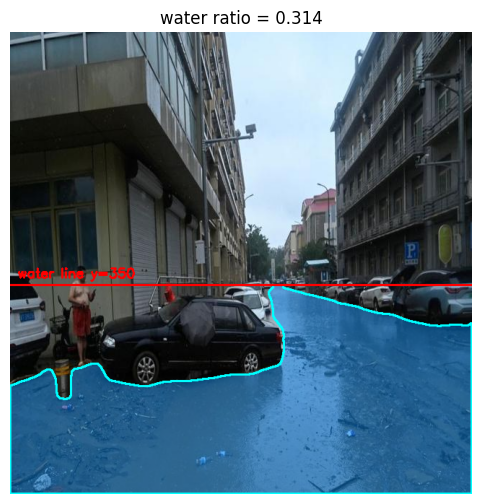

{'water_detected': True, 'water_ratio': 0.31384, 'water_line_y': 350, 'infer_ms': 40.7}


In [8]:
def predict(image_path, wheel_boxes=None, show=True):
    '''이미지 경로 하나만 넣으면 수면 검출 + (선택) 침수레벨까지 반환'''
    if wheel_boxes:
        lv, det, vis = analyze(image_path, wheel_boxes, show=show)
        return {"water_detected": bool(det), "flood_level": lv, "wheels": det}

    r = detect_water(image_path)
    if show:
        plt.figure(figsize=(10, 6))
        plt.imshow(overlay(r["img_rgb"], r["mask"])); plt.axis("off")
        plt.title(f"water ratio = {r['ratio']:.3f}"); plt.show()
    return {"water_detected": r["ratio"] > 0,
            "water_ratio": round(r["ratio"], 5),
            "water_line_y": r["water_y"],
            "infer_ms": round(r["ms"], 1)}


# 사용
print(predict(demo))